In [1]:
!pip install -q -U transformers datasets peft accelerate matplotlib scikit-learn sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 95.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 101.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 41.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.1 requires matplotlib<

In [2]:
!nvidia-smi

Sat Mar 21 09:26:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import transformers, datasets, peft, accelerate, matplotlib, sklearn

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("matplotlib:", matplotlib.__version__)
print("sklearn ok")

transformers: 5.3.0
datasets: 4.8.3
peft: 0.18.1
accelerate: 1.13.0
matplotlib: 3.10.0
sklearn ok


In [4]:
import os
import gc
import json
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 如果你手里有“真正可用的 Qwen-1.3B / 1.5B / 1.8B checkpoint”，改这里即可
MODEL_NAME = "Qwen/Qwen2-1.5B"

OUTPUT_DIR = "./oft_qwen_sst2"
MAX_LENGTH = 96

TRAIN_SAMPLES = 2000
VAL_SAMPLES = 300
TEST_SAMPLES = 300

BATCH_SIZE = 1
GRAD_ACCUM = 4
NUM_EPOCHS = 2
LR = 5e-5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [5]:
from datasets import load_dataset

raw = load_dataset("ag_news")

train_ds = raw["train"].shuffle(seed=SEED).select(range(TRAIN_SAMPLES))
test_all = raw["test"].shuffle(seed=SEED)

val_ds  = test_all.select(range(VAL_SAMPLES))
test_ds = test_all.select(range(VAL_SAMPLES, VAL_SAMPLES + TEST_SAMPLES))

label_map = {
    0: "world",
    1: "sports",
    2: "business",
    3: "science"
}

def make_prompt(text: str) -> str:
    return (
        "Classify the topic of the following news article.\n"
        "Answer with exactly one word from: world, sports, business, science.\n\n"
        f"Article: {text}\n"
        "Answer:"
    )

def convert_example(example):
    prompt = make_prompt(example["text"])
    answer = label_map[int(example["label"])]
    return {
        "text": example["text"],
        "prompt": prompt,
        "answer": answer,
        "full_text": prompt + " " + answer
    }

train_ds = train_ds.map(convert_example)
val_ds   = val_ds.map(convert_example)
test_ds  = test_ds.map(convert_example)

print(train_ds[0]["prompt"])
print("Label:", train_ds[0]["answer"])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Classify the topic of the following news article.
Answer with exactly one word from: world, sports, business, science.

Article: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.
Answer:
Label: world


In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch_dtype,
    trust_remote_code=True
)

model.config.pad_token_id = tokenizer.pad_token_id
print("Loaded model:", MODEL_NAME)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Loaded model: Qwen/Qwen2-1.5B


In [7]:
from peft import OFTConfig, get_peft_model, TaskType

target_modules = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj"
]

peft_config = OFTConfig(
    task_type=TaskType.CAUSAL_LM,
    target_modules=target_modules,
    r=8,
    oft_block_size=0,
    module_dropout=0.0,
    bias="none"
)

model = get_peft_model(model, peft_config)
model = model.to(DEVICE) 
model.print_trainable_parameters()

trainable params: 165,010,944 || all params: 1,708,725,248 || trainable%: 9.6570


In [8]:
def tokenize_for_causal_lm(example):
    prompt = example["prompt"]
    answer = example["answer"]

    prompt_ids = tokenizer(
        prompt,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH
    )["input_ids"]

    answer_ids = tokenizer(
        " " + answer + tokenizer.eos_token,
        add_special_tokens=False,
        truncation=True,
        max_length=16
    )["input_ids"]

    input_ids = prompt_ids + answer_ids
    input_ids = input_ids[:MAX_LENGTH]

    labels = [-100] * len(prompt_ids) + answer_ids
    labels = labels[:MAX_LENGTH]

    attention_mask = [1] * len(input_ids)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

tokenized_train = train_ds.map(
    tokenize_for_causal_lm,
    remove_columns=train_ds.column_names
)
tokenized_val = val_ds.map(
    tokenize_for_causal_lm,
    remove_columns=val_ds.column_names
)

print(tokenized_train[0].keys())

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'attention_mask', 'labels'])


In [9]:
from dataclasses import dataclass
from typing import Dict, List, Any

@dataclass
class CausalLMDataCollator:
    tokenizer: Any
    label_pad_token_id: int = -100

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        input_ids = [f["input_ids"] for f in features]
        attention_mask = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        batch_input = self.tokenizer.pad(
            {"input_ids": input_ids, "attention_mask": attention_mask},
            padding=True,
            return_tensors="pt"
        )

        max_len = batch_input["input_ids"].shape[1]
        padded_labels = []
        for lab in labels:
            padded = lab + [self.label_pad_token_id] * (max_len - len(lab))
            padded_labels.append(padded)

        batch_input["labels"] = torch.tensor(padded_labels, dtype=torch.long)
        return batch_input

data_collator = CausalLMDataCollator(tokenizer)

In [10]:
print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [11]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

def predict_label(model, text, max_new_tokens=3):
    prompt = make_prompt(text)

    model_device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt").to(model_device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    input_len = inputs["input_ids"].shape[1]
    gen_ids = outputs[0][input_len:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip().lower()

    first_word = gen_text.splitlines()[0].strip().split()[0] if gen_text else ""
    first_word = first_word.strip(".,:;!?\"'")

    valid_labels = {"world", "sports", "business", "science"}

    if first_word in valid_labels:
        return first_word, gen_text
    else:
        return "unknown", gen_text


sample_before = test_ds.select(range(5))
for ex in sample_before:
    pred, raw_out = predict_label(model, ex["text"])
    print("TEXT:", ex["text"])
    print("TRUE:", ex["answer"])
    print("PRED:", pred)
    print("RAW :", raw_out)
    print("-" * 60)

Using device: cuda
TEXT: PalmOne to play with Windows Mobile? Rumors of Treo #39;s using a Microsoft operating system have been circulating for more than three years. Now an investment bank reports that PalmOne will use a 
TRUE: science
PRED: business
RAW : business
------------------------------------------------------------
TEXT: Amazon Updates Web Services Tools, Adds Alexa Access The Amazon Web Services (AWS) division of online retail giant Amazon.com yesterday released Amazon E-Commerce Service 4.0 and the beta version of Alexa Web Information Service.
TRUE: science
PRED: business
RAW : business
------------------------------------------------------------
TEXT: ST Tele-TM Intl to buy 47.7 in Idea Mumbai: Singapore Technologies Telemedia and TM International have announced that their consortium has signed definitive agreements for the acquisition of 47.7 per cent stake in Idea Cellular.
TRUE: business
PRED: business
RAW : business
---------------------------------------------------

In [12]:
from tqdm.auto import tqdm

def evaluate_accuracy(model, dataset):
    y_true, y_pred = [], []

    valid_labels = {"world", "sports", "business", "science"}

    for ex in tqdm(dataset, desc="Evaluating"):
        pred, _ = predict_label(model, ex["text"])
        if pred in valid_labels:
            y_true.append(ex["answer"])
            y_pred.append(pred)

    if len(y_true) == 0:
        return 0.0, 0, 0

    acc = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
    return acc, len(y_true), len(dataset)

In [13]:
before_acc, before_used, before_total = evaluate_accuracy(model, test_ds)
print(f"Before finetuning accuracy = {before_acc:.4f} ({before_used}/{before_total})")

Evaluating:   0%|          | 0/300 [00:00<?, ?it/s]

Before finetuning accuracy = 0.7852 (298/300)


In [14]:
sample_before = test_ds.select(range(5))
for ex in sample_before:
    pred, raw_out = predict_label(model, ex["text"])
    print("TEXT:", ex["text"])
    print("TRUE:", ex["answer"])
    print("PRED:", pred)
    print("RAW :", raw_out)
    print("-" * 60)

TEXT: PalmOne to play with Windows Mobile? Rumors of Treo #39;s using a Microsoft operating system have been circulating for more than three years. Now an investment bank reports that PalmOne will use a 
TRUE: science
PRED: business
RAW : business
------------------------------------------------------------
TEXT: Amazon Updates Web Services Tools, Adds Alexa Access The Amazon Web Services (AWS) division of online retail giant Amazon.com yesterday released Amazon E-Commerce Service 4.0 and the beta version of Alexa Web Information Service.
TRUE: science
PRED: business
RAW : business
------------------------------------------------------------
TEXT: ST Tele-TM Intl to buy 47.7 in Idea Mumbai: Singapore Technologies Telemedia and TM International have announced that their consortium has signed definitive agreements for the acquisition of 47.7 per cent stake in Idea Cellular.
TRUE: business
PRED: business
RAW : business
------------------------------------------------------------
TEXT: 46 

In [15]:
model.gradient_checkpointing_enable()
model.config.use_cache = False

In [16]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LR,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=torch.cuda.is_available(),
    bf16=False,
    report_to="none",
    remove_unused_columns=False,
    save_total_limit=2,
    load_best_model_at_end=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator
)

train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Epoch,Training Loss,Validation Loss
1,0.174866,nan
2,0.102076,nan


('./oft_qwen_sst2/tokenizer_config.json',
 './oft_qwen_sst2/chat_template.jinja',
 './oft_qwen_sst2/tokenizer.json')

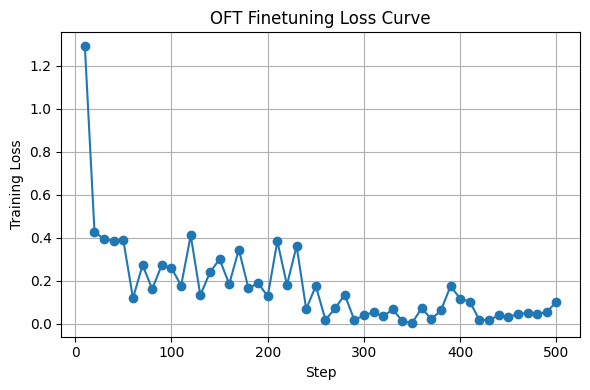

In [17]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]

steps = [x["step"] for x in train_logs]
losses = [x["loss"] for x in train_logs]

plt.figure(figsize=(6,4))
plt.plot(steps, losses, marker="o")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("OFT Finetuning Loss Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig("oft_qwen_loss_curve.png", dpi=200)
plt.show()

In [18]:
for ex in sample_before:
    pred, raw_out = predict_label(model, ex["text"])
    print("TEXT:", ex["text"])
    print("TRUE:", ex["answer"])
    print("PRED:", pred)
    print("RAW :", raw_out)
    print("-" * 60)

TEXT: PalmOne to play with Windows Mobile? Rumors of Treo #39;s using a Microsoft operating system have been circulating for more than three years. Now an investment bank reports that PalmOne will use a 
TRUE: science
PRED: science
RAW : science
------------------------------------------------------------
TEXT: Amazon Updates Web Services Tools, Adds Alexa Access The Amazon Web Services (AWS) division of online retail giant Amazon.com yesterday released Amazon E-Commerce Service 4.0 and the beta version of Alexa Web Information Service.
TRUE: science
PRED: science
RAW : science
------------------------------------------------------------
TEXT: ST Tele-TM Intl to buy 47.7 in Idea Mumbai: Singapore Technologies Telemedia and TM International have announced that their consortium has signed definitive agreements for the acquisition of 47.7 per cent stake in Idea Cellular.
TRUE: business
PRED: business
RAW : business
------------------------------------------------------------
TEXT: 46 Kill

In [19]:
examples_for_report = []

for ex in test_ds.select(range(20)):
    pred, raw_out = predict_label(model, ex["text"])
    examples_for_report.append({
        "text": ex["text"],
        "label": ex["answer"],
        "prediction": pred,
        "raw_output": raw_out
    })

with open("oft_qwen_examples.json", "w", encoding="utf-8") as f:
    json.dump(examples_for_report, f, ensure_ascii=False, indent=2)

print("Saved report examples to oft_qwen_examples.json")

Saved report examples to oft_qwen_examples.json


In [20]:
after_acc, after_used, after_total = evaluate_accuracy(model, test_ds)
print(f"after finetuning accuracy = {after_acc:.4f} ({after_used}/{after_total})")

Evaluating:   0%|          | 0/300 [00:00<?, ?it/s]

after finetuning accuracy = 0.9067 (300/300)
